# Unidad 1 — Exploración y organización de datos acústicos

Los datos acústicos son audios (~1.5 GB) que no están incluidos en el repositorio.

Han sido compartidos mediante enlace externo.

### Ubicación esperada

```
data/audios/
├── Batrachyla_leptopus/
├── Batrachyla_taeniata/
├── Calyptocephalella_gayi/
├── Pleurodema_thaul/
└── Porzana_spiloptera/
```

No modificar nombres ni estructura.

En este cuadernillo trabajaremos con audios de especies acústicas, incluyendo anfibios y el ave *Porzana spiloptera*.

## Objetivos

Aprender a:

- organizar un dataset de audio
- cargar archivos `.wav`
- visualizar señales en el tiempo
- escuchar ejemplos
- explorar la cantidad de audios por clase

## Conceptualmente:

- Antes de aplicar FFT, espectrogramas o aprendizaje automático
- Primero debemos conocer nuestros datos: 
- Qué clases tenemos, cuántos audios hay, cómo se ven en el tiempo y cómo suenan.

## Podemos preguntarnos:


1. ¿Todas las clases tienen la misma cantidad de audios?
2. ¿Las señales tienen duraciones similares?
3. ¿Qué diferencias visuales se observan entre especies/clases?
4. ¿Qué diferencias auditivas se perciben?
5. ¿Por qué es importante organizar bien el dataset antes de procesarlo?

In [1]:
# Importar librerías

from pathlib import Path
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

In [2]:
# Definir ruta del dataset

DATA_DIR = Path("../data/audios")

clases = sorted([carpeta.name for carpeta in DATA_DIR.iterdir() if carpeta.is_dir()])

print("Clases encontradas:")
for clase in clases:
    print("-", clase)

Clases encontradas:
- Batrachyla_leptopus
- Batrachyla_taeniata
- Calyptocephalella_gayi
- Pleurodema_thaul
- Porzana_spiloptera


In [3]:
# Contar audios por clase

conteo = {}

for clase in clases:
    archivos = list((DATA_DIR / clase).glob("*.wav"))
    conteo[clase] = len(archivos)

print("Cantidad de audios por clase:")
for clase, n in conteo.items():
    print(f"{clase}: {n} audios")

Cantidad de audios por clase:
Batrachyla_leptopus: 233 audios
Batrachyla_taeniata: 246 audios
Calyptocephalella_gayi: 247 audios
Pleurodema_thaul: 243 audios
Porzana_spiloptera: 252 audios


In [4]:
# Seleccionar un audio de ejemplo

clase_ejemplo = "Batrachyla_leptopus"

archivo = list((DATA_DIR / clase_ejemplo).glob("*.wav"))[0]

print("Archivo seleccionado:")
print(archivo)

Archivo seleccionado:
../data/audios/Batrachyla_leptopus/audio1062_label7.wav


In [5]:
# Cargar audio

y, sr = librosa.load(archivo, sr=None)

print("Frecuencia de muestreo:", sr)
print("Número de muestras:", len(y))
print("Duración [s]:", len(y) / sr)

Frecuencia de muestreo: 44100
Número de muestras: 56741
Duración [s]: 1.2866439909297052


In [6]:
# Escuchar audio

display(Audio(y, rate=sr))

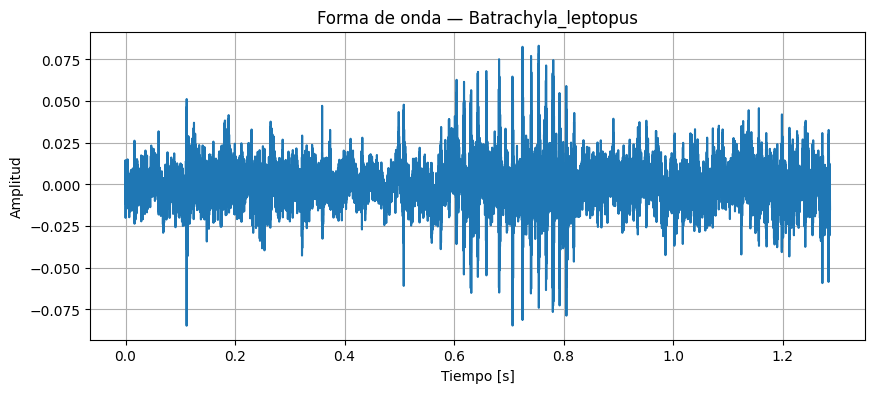

In [7]:
# Graficar forma de onda

t = np.arange(len(y)) / sr

plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.title(f"Forma de onda — {clase_ejemplo}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

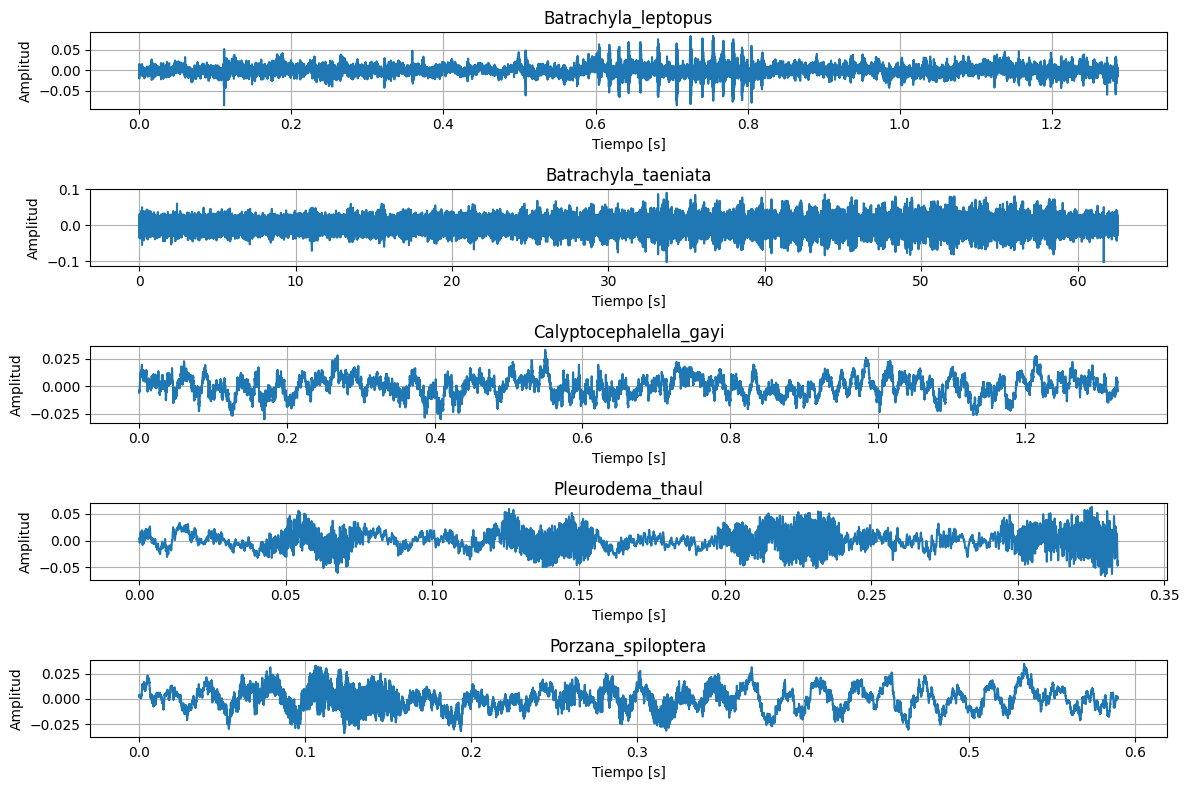

In [8]:
# Comparar una señal por clase

plt.figure(figsize=(12, 8))

for i, clase in enumerate(clases):
    archivo = list((DATA_DIR / clase).glob("*.wav"))[0]
    y, sr = librosa.load(archivo, sr=None)
    t = np.arange(len(y)) / sr

    plt.subplot(len(clases), 1, i + 1)
    plt.plot(t, y)
    plt.title(clase)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid()

plt.tight_layout()
plt.show()